## Import the datasets

In [374]:
from torchvision import datasets, transforms

transform = transforms.ToTensor() # normaliseing betwwen 1 and 2 
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# shape: [1, 28, 28] --> for each channel 

## separate into train/loss//val

In [376]:
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import torch

# Extract all images and labels as tensors
all_images = torch.stack([mnist_full[i][0] for i in range(len(mnist_full))])  # shape: [60000, 1, 28, 28]
all_labels = torch.tensor([mnist_full[i][1] for i in range(len(mnist_full))])  # shape: [60000]

# Split using scikit-learn
X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.1, random_state=42, stratify=all_labels
)

# Wrap back into PyTorch Datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Create DataLoaders
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


## Embedding class + token + positional encoding


Input: [B, I, H, W] → e.g. [32, 1, 28, 28]

Output: [B, num_patches + 1, embed_dim] → e.g. [32, 17, 32]

In [378]:
import torch
import torch.nn as nn


class Embedding(nn.Module):
    def __init__(self, embed_dim =32, num_patches = 16, patch_dim= 49, patch_size = 7):
        super().__init__()

        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)

        self.linear = nn.Linear(patch_dim, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim), requires_grad=True)

    def forward(self, x):
        # x: [B, C, H, W]
        patches = self.unfold(x)               # [B, patch_dim, num_patches]
        patches = patches.transpose(1, 2)      # [B, num_patches, patch_dim]

        x = self.linear(patches)               # [B, num_patches, embed_dim]

        batch_size = x.size(0)
        cls_token = self.cls_token.expand(batch_size, -1, -1)  # [B, 1, embed_dim]

        x = torch.cat([cls_token, x], dim=1)   # [B, num_patches+1, embed_dim]
        x = x + self.pos_embedding             # Add positional encoding

        return x


In [379]:
# Create the model
model = Embedding(patch_size = 7, embed_dim = 32, num_patches = 16, patch_dim= 49 )

# Apply the model to the input tensor
output = model(images)
print(output.shape)

torch.Size([6, 17, 32])


## One head class 

In [381]:
import torch
import torch.nn as nn

class AttentionHead(nn.Module):
    def __init__(self, embed_dim, head_dim):
        super().__init__()
        self.weight_q = nn.Linear(embed_dim, head_dim)
        self.weight_k = nn.Linear(embed_dim, head_dim)
        self.weight_v = nn.Linear(embed_dim, head_dim)

    def forward(self, x):
        #print(f"Input to AttentionHead: {x.shape}")  # [B, T, D]

        Q = self.weight_q(x)
        K = self.weight_k(x)
        V = self.weight_v(x)
        #print(f"Q shape: {Q.shape}, K shape: {K.shape}, V shape: {V.shape}")  # [B, T, head_dim]

        scores = torch.einsum('bid,bjd->bij', Q, K) / (Q.shape[-1] ** 0.5)
        #print(f"Attention scores shape: {scores.shape}")  # [B, T, T]

        A = torch.softmax(scores, dim=-1)
        H = torch.einsum('bij,bjd->bid', A, V)
        #print(f"Output H shape: {H.shape}")  # [B, T, head_dim]

        return H


In [382]:
# Create the model
x = torch.randn(32, 17, 32)
model = AttentionHead(head_dim =8, embed_dim = 32)

# Apply the model to the input tensor
output = model(x)
print('Successull')

Successull


## Multi head class 

In [384]:
class Multihead(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads

        self.heads = nn.ModuleList([
            AttentionHead(embed_dim, self.head_dim) for _ in range(num_heads)
        ])
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        #print(f"Input to Multihead: {x.shape}")  # [B, T, D]

        head_outputs = []
        for i, head in enumerate(self.heads):
            #print(f"\nRunning head {i}")
            out = head(x)
            #print(f"Head {i} output shape: {out.shape}")
            head_outputs.append(out)

        concat = torch.cat(head_outputs, dim=-1)
        #print(f"Concatenated heads shape: {concat.shape}")  # [B, T, embed_dim]

        final = self.out_proj(concat) 
        #print(f"Output of Multihead after out_proj: {final.shape}")
        return final
                       # [B, T, embed_dim]


In [385]:
# Create the model
x = torch.randn(32, 17, 32)
model = Multihead(embed_dim=32, num_heads=4)

# Apply the model to the input tensor
output = model(x)
print('Successull')

Successull


## Encoder block 

In [387]:
# now that we have a single Head Attention Layer, and know how to use it in a multi-head context, we can build the encoder block
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dimension):
        super(EncoderBlock, self).__init__()

        # normalisation layer before attention
        self.ln1 = nn.LayerNorm(embed_dim)

        # create a multi-head attention layer
        self.mha = Multihead(embed_dim, num_heads)


        # create a feed forward network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, mlp_dimension),  # W₁, b₁
            nn.ReLU(),                               # max(0, x)
            nn.Linear(mlp_dimension, embed_dim)   # W₂, b₂
        )

        # normalisation layer after attention
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # first attention block with residual connection
        x = self.ln1(x + self.mha(x))

        # FFN block with residual connection
        x = self.ln2(self.ffn(x) + x)

        return x

In [388]:
# Create the model
x = torch.randn(32, 17, 32) 
encoder = EncoderBlock(embed_dim=32, num_heads=4, mlp_dimension=32)

# Apply the model to the input tensor
output = encoder(x)

print("Encoder output shape:", output.shape)

Encoder output shape: torch.Size([32, 17, 32])


test to see if it works 

## classification block

In [391]:

import torch.nn.functional as F

class TransformerModel(nn.Module):
    def __init__(self, patch_dim, num_patches, embed_dim, num_heads, num_layers, num_classes, mlp_dim):
        super().__init__()

        # Embedding layer (patch projection + CLS token + pos encoding)
        self.embedding = Embedding(embed_dim =32, num_patches = 16, patch_dim= 49, patch_size = 7)

        # Stack of Encoder blocks
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(embed_dim=embed_dim, num_heads=num_heads, mlp_dimension=mlp_dim)
            for _ in range(num_layers)
        ])

        # Classification head (on the [CLS] token)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)  # [B, num_patches+1, embed_dim]
        for block in self.encoder_blocks:
            x = block(x)  # [B, T, D]

        cls_token = x[:, 0]  # [B, D]
        logits = self.classifier(cls_token)  # [B, num_classes]

        return F.softmax(logits, dim=-1)  # Probabilities over classes

 

In [392]:
# Create the model
model = TransformerModel(
    patch_dim= 49,          # each patch is length 49
    num_patches= 17,        # each input has 16 patches
    embed_dim= 32,          # embedding dimension
    num_heads= 4,           # 4 attention heads    # 2 transformer encoder blocks
    num_classes=10,
    num_layers = 1,
    mlp_dim= 64             # dimension inside the feedforward MLP
)

# Apply the model to the input tensor
output = model(images)

print("Encoder output shape:", output.shape)

Encoder output shape: torch.Size([6, 10])


## Training loop 

In [394]:

model.train()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [395]:
!pip install wandb


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


Weight and biases 

In [397]:

import wandb
import datetime

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M_%S')


wandb.init(
    project="transformer",
    name=f"single-digit-problem-{timestamp}",
    config={
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.001
})

In [399]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)


for epoch in range(10):
    model.train()
    total_loss = 0

    for image, label in loader:

        # Forward pass
        logits = model(image)
        loss = criterion(logits, label)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    # --- Validation Loop ---
    model.eval()
    val_losses = []
    correct = 0
    total = 0

    with torch.no_grad():
        for image, label in val_loader:
            #image = image.to(device)
            #label = label.to(device)

            outputs = model(image)
            val_loss = criterion(outputs, label)
            val_losses.append(val_loss.item())

            _, predicted = outputs.max(1)
            correct += predicted.eq(label).sum().item()
            total += label.size(0)

    avg_val_loss = sum(val_losses) / len(val_losses)
    val_accuracy = correct / total

    # Log to wandb
    wandb.log({
        "Epoch": epoch + 1,
        "Train Loss": avg_loss,
        "Val Loss": avg_val_loss,
        "Val Accuracy": val_accuracy
    })

    print(f"📉 Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

wandb.finish()






📉 Epoch 1 | Train Loss: 1.5635 | Val Loss: 1.5481 | Val Acc: 0.9162
📉 Epoch 2 | Train Loss: 1.5467 | Val Loss: 1.5491 | Val Acc: 0.9145
📉 Epoch 3 | Train Loss: 1.5389 | Val Loss: 1.5408 | Val Acc: 0.9222
📉 Epoch 4 | Train Loss: 1.5340 | Val Loss: 1.5258 | Val Acc: 0.9357
📉 Epoch 5 | Train Loss: 1.5310 | Val Loss: 1.5316 | Val Acc: 0.9307
📉 Epoch 6 | Train Loss: 1.5268 | Val Loss: 1.5231 | Val Acc: 0.9382
📉 Epoch 7 | Train Loss: 1.5250 | Val Loss: 1.5245 | Val Acc: 0.9387
📉 Epoch 8 | Train Loss: 1.5218 | Val Loss: 1.5199 | Val Acc: 0.9418
📉 Epoch 9 | Train Loss: 1.5199 | Val Loss: 1.5190 | Val Acc: 0.9432
📉 Epoch 10 | Train Loss: 1.5180 | Val Loss: 1.5203 | Val Acc: 0.9415


Epoch,▁▂▃▃▄▅▆▆▇█
Train Loss,█▅▄▃▃▂▂▂▁▁
Val Accuracy,▁▁▃▆▅▇▇███
Val Loss,██▆▃▄▂▂▁▁▁
Epoch,10
Train Loss,1.51801
Val Accuracy,0.9415
Val Loss,1.52033


In [405]:
# Save the model's state_dict (recommended)
torch.save(model.state_dict(), "mnist_model_test.pth")


## test model 

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the same transform as for training
transform = transforms.ToTensor()

# Download the test set
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoader
test_loader = DataLoader(mnist_test, batch_size=32, shuffle=False)

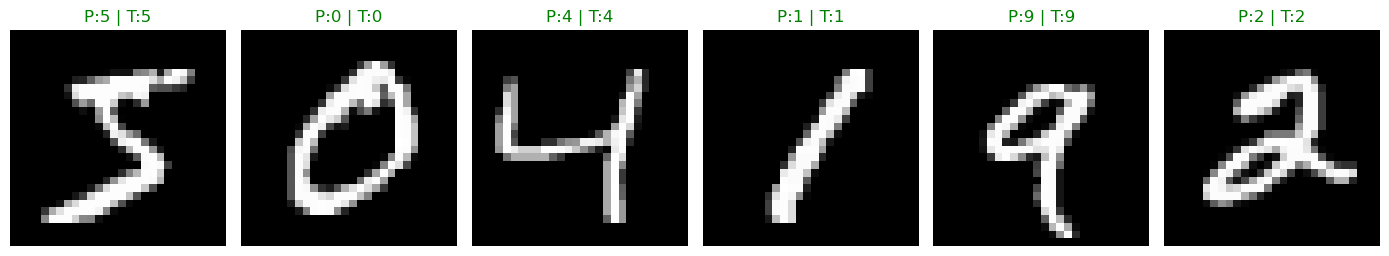

In [403]:
import torch
import matplotlib.pyplot as plt

# 1. Take 6 random samples from your MNIST dataset
examples = [mnist[i] for i in range(6)]
images = torch.stack([img for img, _ in examples])       # shape: [6, 1, 28, 28]
labels = [label for _, label in examples]                # list of true labels

# 2. Pass images through your trained model
model.eval()
with torch.no_grad():
    #images_device = images.to(device)                    # move to GPU if needed
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)           # predicted class indices

# 3. Plot the images with predicted and true labels
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i][0].cpu(), cmap='gray')           # image is [1, 28, 28]
    pred = predictions[i].item()
    true = labels[i]
    color = 'green' if pred == true else 'red'
    ax.set_title(f"P:{pred} | T:{true}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()
